In [221]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
pd.options.display.max_columns= None

In [222]:
path= 'Loan_Default.csv'
data= pd.read_csv(path)
df= data.copy()

## EDA

+ missings
+ duplicates
+ data imbalance
+ matching-relations
+ outliers
+ rare labels

In [223]:
print(df.shape)
print('----------')
print(df.dtypes.value_counts())
print('----------')
print(df.isna().sum())

(148670, 34)
----------
object     21
float64     8
int64       5
Name: count, dtype: int64
----------
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score          

In [224]:
msno.matrix(df)

<Axes: >

In [225]:
df.head(3)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0


In [226]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [227]:
#duplicates
print('Nb of duplicates:',df.duplicated().sum())
multiple_loans= df.duplicated(subset= ['Gender','income','Credit_Score','age','Region'])
print('Nb of ppl with multiple loans:',multiple_loans.sum())

Nb of duplicates: 0
Nb of ppl with multiple loans: 6578


In [228]:
from IPython.display import HTML

# Calculate statistics
counts = df['Status'].value_counts()
percents = df['Status'].value_counts(normalize=True) * 100

# Generate HTML table
html_table = "<table><tr><th>Status</th><th>Value Count</th><th>Percentage</th></tr>"
for index, value in counts.items():
    html_table += f"<tr><td>{index}</td><td>{value}</td><td>{percents[index]:.2f}%</td></tr>"
html_table += "</table>"

display(HTML(html_table))

Status,Value Count,Percentage
0,112031,75.36%
1,36639,24.64%


In [229]:
from IPython.display import HTML
import pandas as pd

# 1. Identify unique statuses to prevent "0%" mapping errors
unique_statuses = df['Status'].unique()

# 2. Get missing counts and sort
missing_data = df.isna().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# 3. Create HTML with a dark-colored header (#2c3e50)
html = """<table style='width:100%; border-collapse: collapse; font-family: Arial, sans-serif;'>
<tr style='background-color: #2c3e50; color: white; text-align: left;'>
    <th style='padding: 12px;'>Feature</th>
    <th style='padding: 12px;'>NaN Count</th>
    <th style='padding: 12px;'>% Missing</th>"""

for s in unique_statuses:
    html += f"<th style='padding: 12px;'>% {s} (within NaN)</th>"
html += "</tr>"

# 4. Populate rows
for col, count in missing_data.items():
    pct_missing = (count / len(df)) * 100
    nan_subset_status = df[df[col].isna()]['Status']
    status_dist = nan_subset_status.value_counts(normalize=True) * 100
    
    html += f"<tr><td style='border-bottom: 1px solid #ddd; padding: 10px;'>{col}</td>"
    html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{count}</td>"
    html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{pct_missing:.2f}%</td>"
    
    for s in unique_statuses:
        val = status_dist.get(s, 0)
        html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{val:.2f}%</td>"
    html += "</tr>"

html += "</table>"
display(HTML(html))


Feature,NaN Count,% Missing,% 1 (within NaN),% 0 (within NaN)
Upfront_charges,39642,26.66%,92.04%,7.96%
Interest_rate_spread,36639,24.64%,100.00%,0.00%
rate_of_interest,36439,24.51%,100.00%,0.00%
dtir1,24121,16.22%,67.62%,32.38%
property_value,15098,10.16%,99.99%,0.01%
LTV,15098,10.16%,99.99%,0.01%
income,9150,6.15%,13.54%,86.46%
loan_limit,3344,2.25%,26.35%,73.65%
approv_in_adv,908,0.61%,26.54%,73.46%
age,200,0.13%,100.00%,0.00%


In [230]:
print('unique ids:',len(df['ID'].unique()) == len(df)) # unique Ids
print('years recorded loans:', df['year'].unique())

unique ids: True
years recorded loans: [2019]


In [231]:
# 1. Filter for categorical (object) columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif;'>
<tr style='background-color: #34495e; color: white;'>
    <th style='padding: 10px;'>Column</th>
    <th style='padding: 10px;'>Cardinality</th>
    <th style='padding: 10px;'>Value Distribution (Count & %)</th>
</tr>"""

for col in cat_cols:
    cardinality = df[col].nunique()
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    
    # Create a string for value distribution
    dist_str = "<br>".join([f"<b>{k}</b>: {v} ({percents[k]:.1f}%)" for k, v in counts.items()])
    
    html += f"<tr><td style='border: 1px solid #ddd; padding: 8px;'>{col}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{cardinality}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{dist_str}</td></tr>"

html += "</table>"
display(HTML(html))

Column,Cardinality,Value Distribution (Count & %)
loan_limit,2,cf: 135348 (93.1%)ncf: 9978 (6.9%)
Gender,4,Male: 42346 (28.5%)Joint: 41399 (27.8%)Sex Not Available: 37659 (25.3%)Female: 27266 (18.3%)
approv_in_adv,2,nopre: 124621 (84.3%)pre: 23141 (15.7%)
loan_type,3,type1: 113173 (76.1%)type2: 20762 (14.0%)type3: 14735 (9.9%)
loan_purpose,4,p3: 55934 (37.7%)p4: 54799 (36.9%)p1: 34529 (23.2%)p2: 3274 (2.2%)
Credit_Worthiness,2,l1: 142344 (95.7%)l2: 6326 (4.3%)
open_credit,2,nopc: 148114 (99.6%)opc: 556 (0.4%)
business_or_commercial,2,nob/c: 127908 (86.0%)b/c: 20762 (14.0%)
Neg_ammortization,2,not_neg: 133420 (89.8%)neg_amm: 15129 (10.2%)
interest_only,2,not_int: 141560 (95.2%)int_only: 7110 (4.8%)


In [232]:
iterative_drop_cols= ['loan_limit','Credit_Worthiness','open_credit','interest_only',
                      'lump_sum_payment','construction_type','occupancy_type','Secured_by',
                      'total_units','Security_Type', 'ID','year','Interest_rate_spread',
                      'Upfront_charges','credit_type']
#Upfront_charges/Interest_rate_spread are set after risk assessment, not viable for us
# id / year not predictive
# others are extremely imbalanced labels

In [233]:
# outliers:
df.select_dtypes(include= 'number').columns

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [234]:
counts = df['term'].value_counts()
total_len = len(df)

# 2. Identify the 'Default' label (Assumes 1 or 'Default')
# Adjust 'Default' if your label is different (e.g., 1)
default_val = 'Default' if 'Default' in df['Status'].unique() else 1

# 3. Build the Table
html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif;'>
<tr style='background-color: #8e44ad; color: white;'>
    <th style='padding: 10px;'>Term (Months)</th>
    <th style='padding: 10px;'>Frequency</th>
    <th style='padding: 10px;'>% of Total</th>
    <th style='padding: 10px;'>Default Rate (%)</th>
</tr>"""

for term, count in counts.items():
    pct_total = (count / total_len) * 100
    
    # Calculate % of defaults for this specific term
    subset = df[df['term'] == term]
    def_count = (subset['Status'] == default_val).sum()
    def_rate = (def_count / len(subset)) * 100
    
    html += f"<tr><td style='border: 1px solid #ddd; padding: 8px;'>{term}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{count}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{pct_total:.2f}%</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{def_rate:.2f}%</td></tr>"

html += "</table>"
display(HTML(html))

Term (Months),Frequency,% of Total,Default Rate (%)
360.0,121685,81.85%,24.21%
180.0,12981,8.73%,24.30%
240.0,5859,3.94%,20.82%
300.0,2822,1.90%,56.56%
324.0,2766,1.86%,25.42%
120.0,510,0.34%,18.24%
144.0,263,0.18%,17.49%
348.0,260,0.17%,20.38%
336.0,213,0.14%,18.31%
96.0,194,0.13%,20.62%


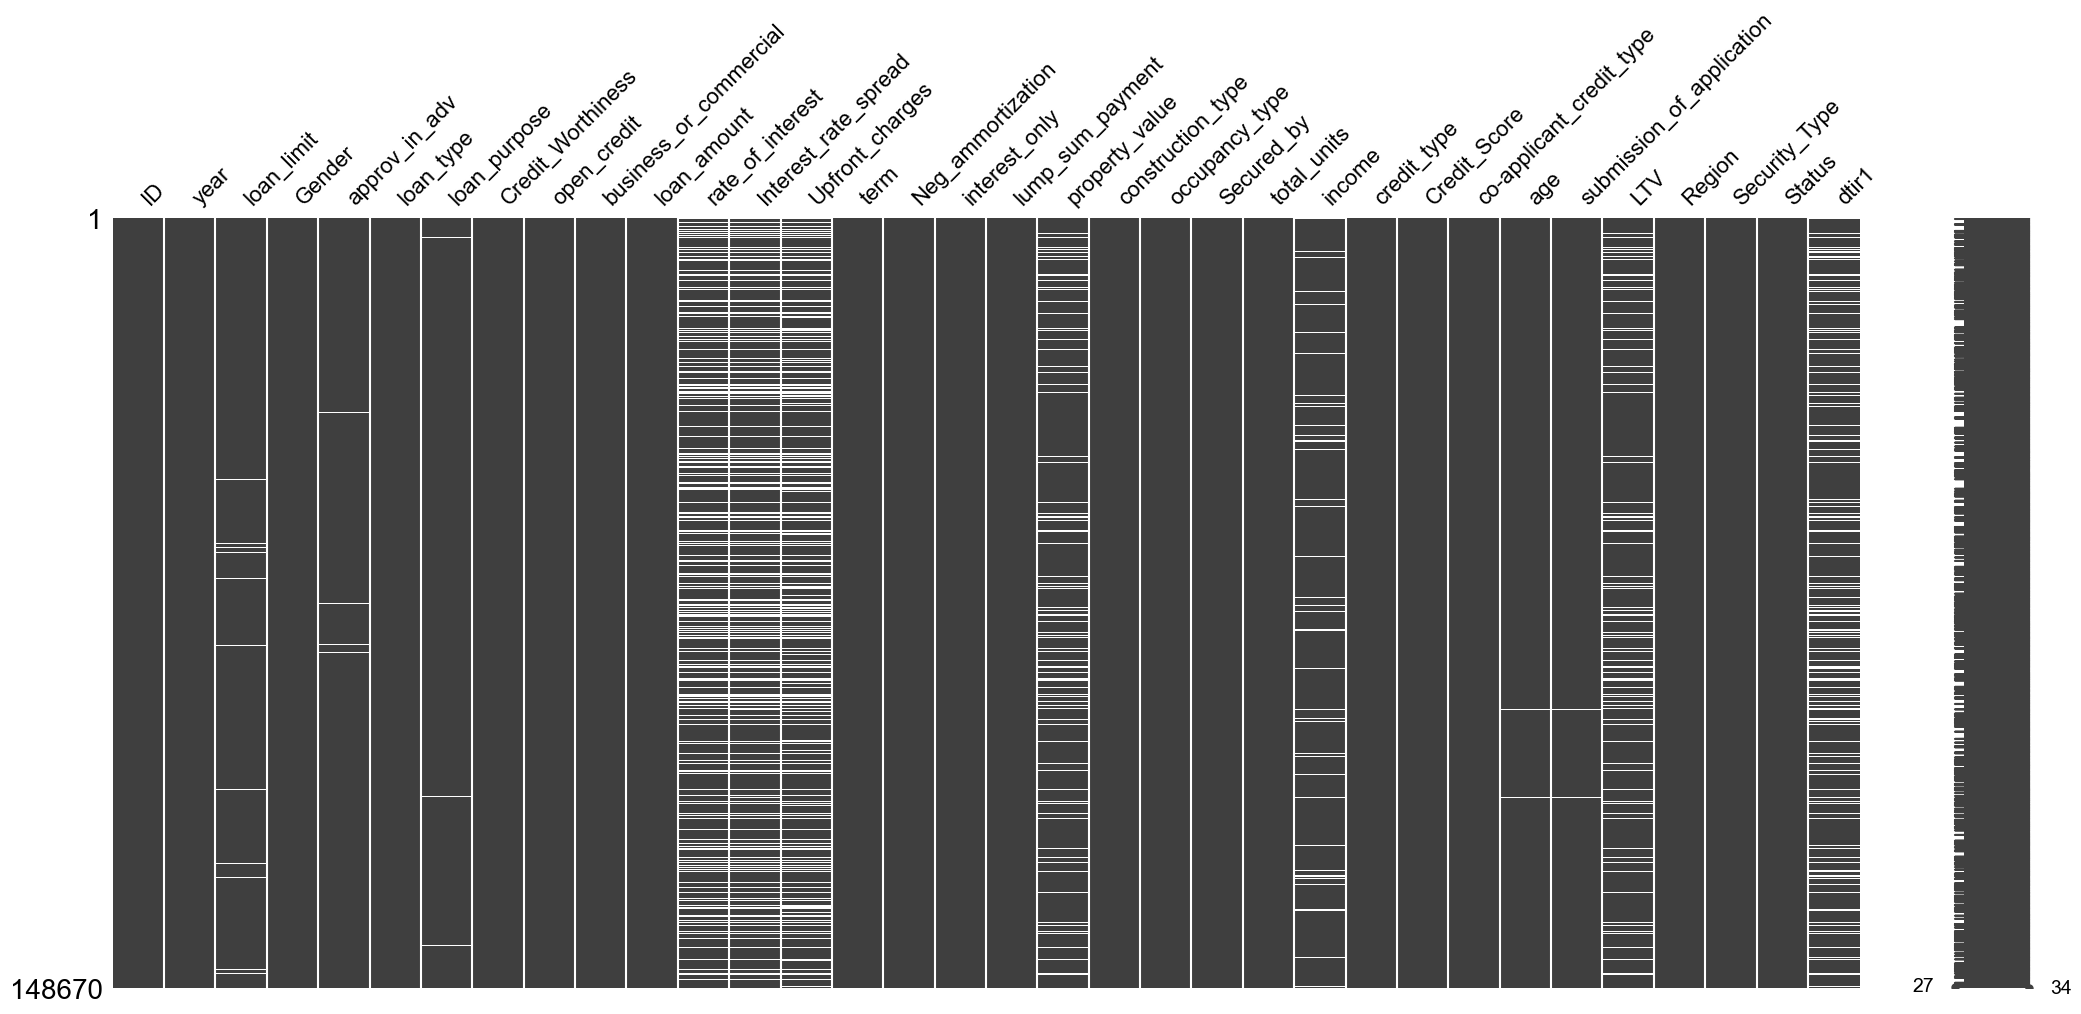

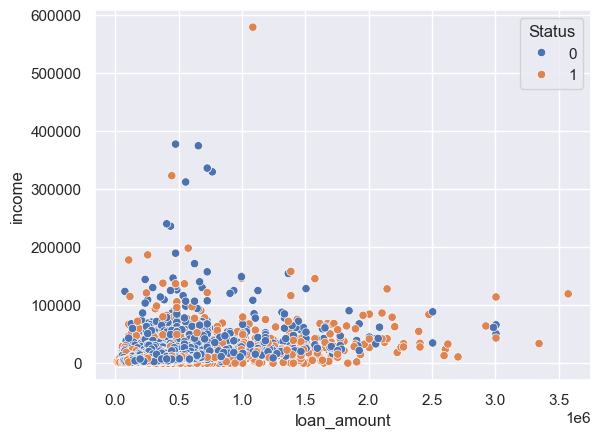

In [235]:
sns.set()
plt.figure()
sns.scatterplot(data= df, x='loan_amount',y='income', hue='Status')
plt.show()

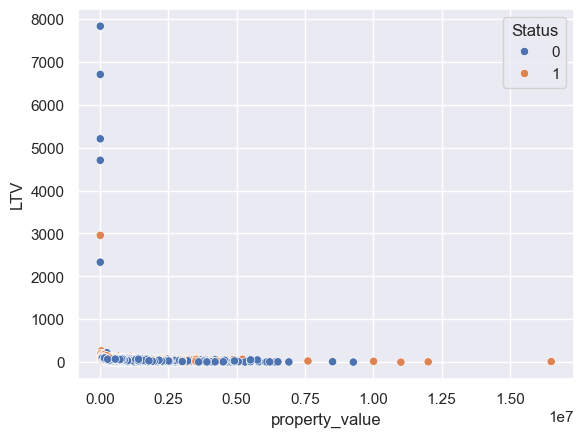

In [236]:
plt.figure()
sns.scatterplot(data= df, x= 'property_value', y='LTV', hue='Status')
plt.show()

In [237]:
df[['income','loan_amount','LTV','property_value']].describe().round(1)

,income,loan_amount,LTV,property_value
count,139520.0,148670.0,133572.0,133572.0
mean,6957.3,331117.7,72.7,497893.5
std,6496.6,183909.3,40.0,359935.3
min,0.0,16500.0,1.0,8000.0
25%,3720.0,196500.0,60.5,268000.0
50%,5760.0,296500.0,75.1,418000.0
75%,8520.0,436500.0,86.2,628000.0
max,578580.0,3576500.0,7831.2,16508000.0


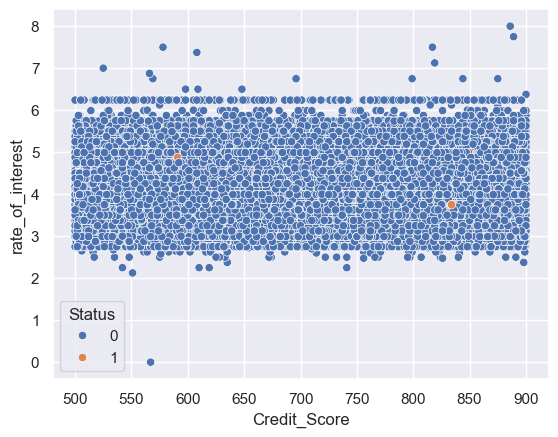

In [238]:
plt.figure()
sns.scatterplot(data= df, x='Credit_Score', y='rate_of_interest', hue='Status')
plt.show()

In [239]:
oi= []
oi.extend(df[df['income']> 200_000].index)
oi.extend(df[df['income']==0].index)
oi.extend(df[df['loan_amount']> 2_500_000].index)
oi.extend(df[df['LTV']>100].index)
oi.extend(df[df['property_value']>7_000_000].index)
oi.extend(df[df['rate_of_interest']==0].index)

## Feature Selection

+ Iterative Imputer
**removing-ouliters > filling nan**
+ IV ranking
+ VIF ranking
+ correlation matrix
+ Tree-Based importance
+ Domain knowledge

In [240]:
df= df.drop(iterative_drop_cols, axis= 1)
df =df.drop(list(set(oi)))
df= df.reset_index(drop= True)
df.columns

Index(['Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'business_or_commercial', 'loan_amount', 'rate_of_interest', 'term',
       'Neg_ammortization', 'property_value', 'income', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV',
       'Region', 'Status', 'dtir1'],
      dtype='object')

In [241]:
from sklearn.model_selection import train_test_split as tts
x_train, x_test, y_train, y_test= tts(df.drop('Status',axis= 1), df['Status'], test_size=.2, stratify= df['Status'])

In [242]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
ohe_cols= ['Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
           'business_or_commercial','Neg_ammortization',
           'co-applicant_credit_type','submission_of_application','Region']
ore_cols= ['age']
age_order= ['<25','25-34', '35-44', '45-54','55-64', '65-74', '>74']
ore= OrdinalEncoder(categories= [age_order], handle_unknown='use_encoded_value',unknown_value=np.nan,
                    encoded_missing_value=np.nan)
ohe= OneHotEncoder(handle_unknown='ignore')
x_train[['age']]= ore.fit_transform(x_train[['age']])
ohe_output = ohe.fit_transform(x_train[ohe_cols])
new_cols = ohe.get_feature_names_out(ohe_cols)
ohe_df = pd.DataFrame(ohe_output.toarray(), columns=new_cols, index=x_train.index)
x_train = x_train.drop(columns=ohe_cols).join(ohe_df)
x_test[['age']] = ore.transform(x_test[['age']])
ohe_test_output = ohe.transform(x_test[ohe_cols])
ohe_test_df = pd.DataFrame(ohe_test_output.toarray(), columns=new_cols, index=x_test.index)
x_test = x_test.drop(columns=ohe_cols).join(ohe_test_df)

In [243]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
iter_imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1),
    max_iter=3,
    random_state=42
)
x_train_iter= iter_imp.fit_transform(x_train)
x_test_iter= iter_imp.transform(x_test)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


**simple xgboost to validate iterImpute**

In [244]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report as cr
from sklearn.impute import SimpleImputer
si= SimpleImputer(strategy= 'median')
x_train= si.fit_transform(x_train)
x_test= si.transform(x_test)
xgb_orig= XGBClassifier(class_weight= 'balanced')
xgb_iter= XGBClassifier(class_weight= 'balanced')
xgb_orig.fit(x_train, y_train)
xgb_iter.fit(x_train_iter, y_train)
print('ORIGINAL DATA')
print(cr(y_test, xgb_orig.predict(x_test)))
print('-----------------------')
print('Imputed DATA')
print(cr(y_test, xgb_iter.predict(x_test_iter)))

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:17:12] WARNING: D:\bld\xgboost-split_1764148481205\work\src\learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ORIGINAL DATA
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     22276
           1       0.86      0.86      0.86      6841

    accuracy                           0.93     29117
   macro avg       0.91      0.91      0.91     29117
weighted avg       0.93      0.93      0.93     29117

-----------------------
Imputed DATA
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     22276
           1       0.99      0.98      0.98      6841

    accuracy                           0.99     29117
   macro avg       0.99      0.99      0.99     29117
weighted avg       0.99      0.99      0.99     29117



**Our iterativeImputer did a good job, we'll transform the entire df dataframe now**

In [245]:
ore = OrdinalEncoder(categories=[age_order], handle_unknown='use_encoded_value', 
                     unknown_value=np.nan, encoded_missing_value=np.nan)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

df_enc = df.copy()
df_enc[['age']] = ore.fit_transform(df[['age']])
ohe_data = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)
df_ready = df_enc.drop(columns=ohe_cols).join(ohe_df)

iter_imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1),
    max_iter=3,
    initial_strategy='most_frequent',
    random_state=42
)

df_imputed_arr = iter_imp.fit_transform(df_ready)
df_imputed = pd.DataFrame(df_imputed_arr, columns=df_ready.columns, index=df.index)

df[ohe_cols] = ohe.inverse_transform(df_imputed[ohe.get_feature_names_out(ohe_cols)])
df[['age']] = ore.inverse_transform(df_imputed[['age']])

remaining = df_ready.columns.difference(ohe.get_feature_names_out(ohe_cols)).difference(['age'])
df[remaining] = df_imputed[remaining]

df = df.fillna(df.mode().iloc[0])

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [246]:
from optbinning import BinningProcess
from IPython.display import display, HTML

cols = df.columns.drop('Status').tolist()
bin_proc = BinningProcess(variable_names=cols)
bin_proc.fit(df[cols], df['Status'])

iv_df = bin_proc.summary().reset_index()
iv_df = iv_df.rename(columns={'name': 'column'})[['column', 'iv']]
iv_df = iv_df.sort_values(by="iv", ascending=False)

def color_iv(val):
    color = 'lightpink' if val < 0.02 else 'lightgreen'
    return f'background-color: {color}'

html_output = iv_df.style.map(color_iv, subset=['iv']).to_html()
display(HTML(html_output))

,column,iv
6,rate_of_interest,0.937477
9,property_value,0.144128
17,dtir1,0.125435
12,co-applicant_credit_type,0.117403
8,Neg_ammortization,0.116507
15,LTV,0.116049
10,income,0.103587
14,submission_of_application,0.088346
5,loan_amount,0.045577
0,Gender,0.039400


In [247]:
weak_features = iv_df[iv_df['iv'] < 0.02]['column'].tolist()
weak_features

['age', 'Region', 'loan_purpose', 'approv_in_adv', 'term', 'Credit_Score']

In [248]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display, HTML

num_df = df.select_dtypes(include=[np.number]).drop(columns=['Status'])
vif_data = pd.DataFrame()
vif_data["column"] = num_df.columns
vif_data["VIF"] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

def color_vif(val):
    color = 'lightpink' if val > 5 else 'lightgreen'
    return f'background-color: {color}'

html_output = vif_data.style.map(color_vif, subset=['VIF']).to_html()
display(HTML(html_output))

,column,VIF
1,rate_of_interest,47.898088
2,term,38.723235
6,LTV,35.408044
5,Credit_Score,28.887426
0,loan_amount,18.447478
7,dtir1,17.966586
3,property_value,14.378112
4,income,4.080547


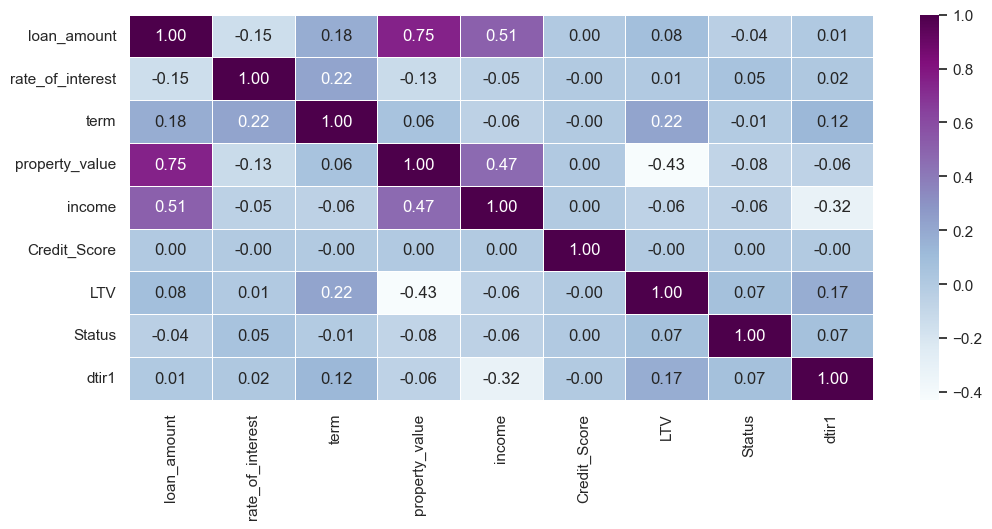

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='BuPu', linewidths=0.5)
plt.show()

In [250]:
weak_features.append('property_value')
# also dropping property_value

## Feature Engineering

In [251]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

def calculate_ratios(X):
    X = X.copy()
    X['LTI'] = X['loan_amount'] / (X['income'] * 12)
    X['annual_disposable_income'] = (X['income'] * 12) - X['loan_amount']
    X['monthly_installment'] = X['loan_amount'] / X['term']
    X['interest_burden'] = (X['loan_amount'] * (X['rate_of_interest'] / 100)) / X['property_value']
    return X

class GroupCountTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, identifier_cols):
        self.identifier_cols = identifier_cols
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X['loan_count'] = X.groupby(self.identifier_cols, dropna=False)['loan_amount'].transform('count')
        return X

class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.drop(columns=[c for c in self.columns_to_drop if c in X.columns])

identifier_cols = ['Gender', 'approv_in_adv', 'income', 'Credit_Score', 'age', 'Region']
drop_list = list(set(weak_features + ['property_value', 'income']))

feature_pipeline = Pipeline([
    ('ratios', FunctionTransformer(calculate_ratios)),
    ('group_counts', GroupCountTransformer(identifier_cols)),
    ('selector', ColumnDropper(drop_list))
])

df = feature_pipeline.fit_transform(df)

In [252]:
cols = df.columns.drop('Status').tolist()
bin_proc = BinningProcess(variable_names=cols)
bin_proc.fit(df[cols], df['Status'])

iv_df = bin_proc.summary().reset_index()
iv_df = iv_df.rename(columns={'name': 'column'})[['column', 'iv']]
iv_df = iv_df.sort_values(by="iv", ascending=False)

def color_iv(val):
    color = 'lightpink' if val < 0.02 else 'lightgreen'
    return f'background-color: {color}'

html_output = iv_df.style.map(color_iv, subset=['iv']).to_html()
display(HTML(html_output))

,column,iv
4,rate_of_interest,0.937477
13,interest_burden,0.162616
9,dtir1,0.125435
6,co-applicant_credit_type,0.117403
5,Neg_ammortization,0.116507
8,LTV,0.116049
7,submission_of_application,0.088346
10,LTI,0.072875
12,monthly_installment,0.048004
3,loan_amount,0.045577


In [253]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['Status'])
vif_data = pd.DataFrame()
vif_data["column"] = num_df.columns
vif_data["VIF"] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)

def color_vif(val):
    color = 'lightpink' if val > 5 else 'lightgreen'
    return f'background-color: {color}'

html_output = vif_data.style.map(color_vif, subset=['VIF']).to_html()
display(HTML(html_output))

,column,VIF
7,interest_burden,103.555249
2,LTV,96.168525
0,loan_amount,64.622241
1,rate_of_interest,51.380490
5,annual_disposable_income,32.116183
8,loan_count,23.265297
6,monthly_installment,20.322240
3,dtir1,18.720883
4,LTI,1.441007


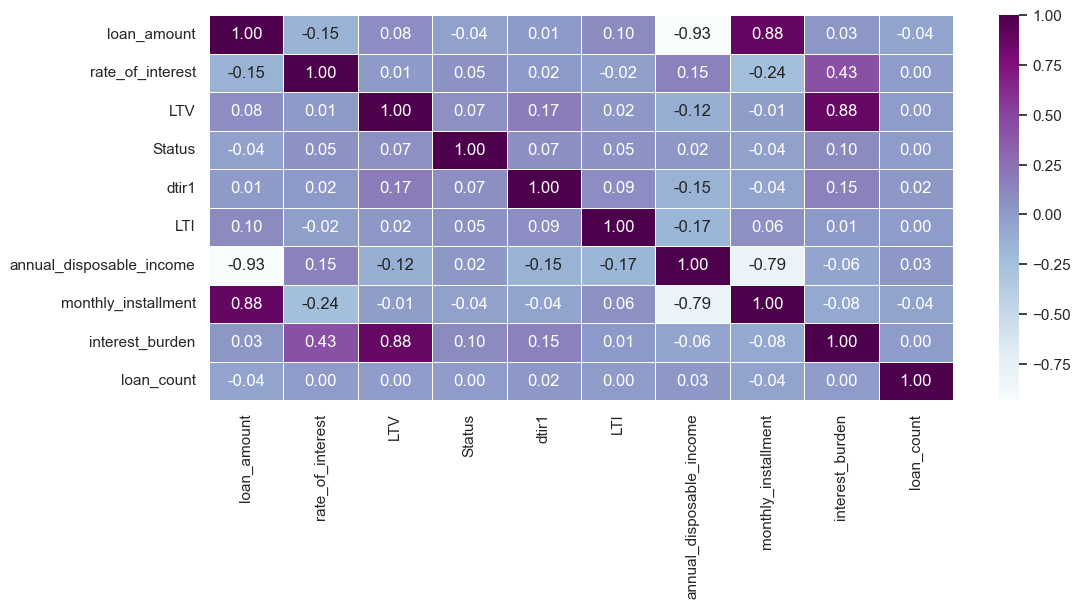

In [254]:
plt.figure(figsize=(12, 5))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='BuPu', linewidths=0.5)
plt.show()

## Preprocessing

In [255]:
# Custom wrapper to ensure optbinning works seamlessly in a Sklearn Pipeline
class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, binning_process):
        self.binning_process = binning_process
    
    def fit(self, X, y):
        self.binning_process.fit(X, y)
        return self
    
    def transform(self, X):
        # transform() returns the WoE values
        return self.binning_process.transform(X, metric="woe")

# 1. Define variables (excluding target)
x_cols = df.columns.drop('Status').tolist()
y = df['Status']

# 2. Initialize BinningProcess
bin_proc = BinningProcess(variable_names=x_cols)

# 3. Create and fit the Pipeline
woe_pipeline = Pipeline([
    ('woe_transform', WoETransformer(bin_proc))
])

df_woe_array = woe_pipeline.fit_transform(df[x_cols], y)

# 4. Convert back to DataFrame with original column names
df_woe = pd.DataFrame(df_woe_array, columns=x_cols, index=df.index)

## Model selection

In [256]:
inputs= df_woe
target= df['Status']
x_train, x_test, y_train, y_test= tts(inputs, target, test_size= .2, stratify= target)

In [257]:
from sklearn.linear_model import LogisticRegression

log_reg_fast = LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs')

param_dist_fast = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'fit_intercept': [True, False]
}


## Model Tuning

In [258]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

# 3. Simpler CV: 3-fold stratified (no repeats)
cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4. Reduced Iterations
random_search_fast = RandomizedSearchCV(
    estimator=log_reg_fast,
    param_distributions=param_dist_fast,
    n_iter=10, 
    cv=cv_fast,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

random_search_fast.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,LogisticRegre...max_iter=1000)
,param_distributions,"{'C': [0.001, 0.01, ...], 'fit_intercept': [True, False]}"
,n_iter,10
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


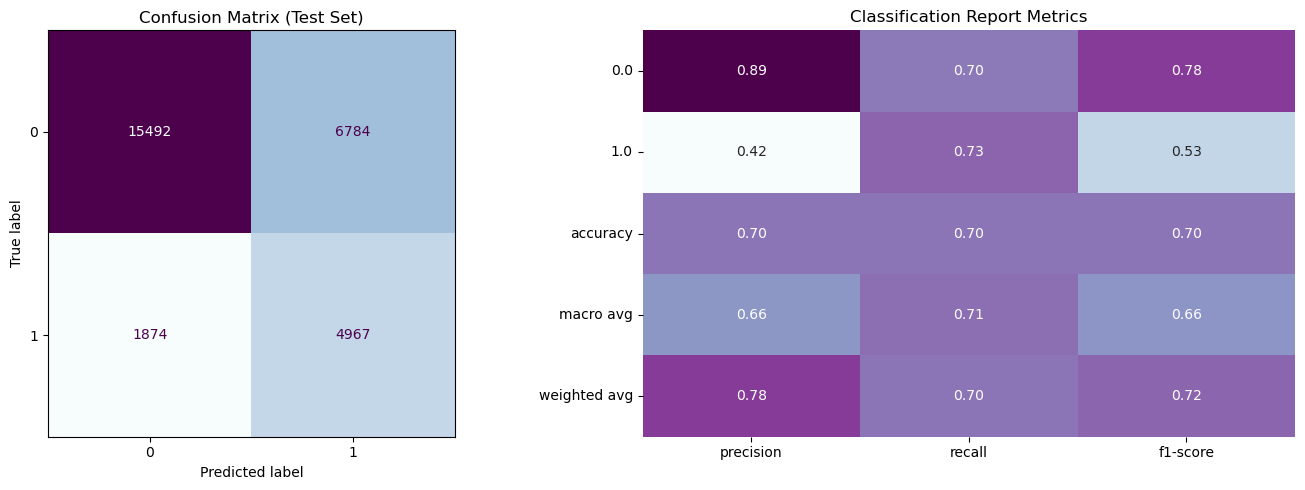

In [259]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
sns.reset_defaults()
# 1. Generate predictions
y_pred = random_search_fast.best_estimator_.predict(x_test)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :].T  # Exclude support row and transpose

# 2. Setup Figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='BuPu', ax=ax[0], colorbar=False)
ax[0].set_title('Confusion Matrix (Test Set)')

# Right: Classification Report Heatmap
sns.heatmap(report_df, annot=True, cmap='BuPu', cbar=False, ax=ax[1], fmt='.2f')
ax[1].set_title('Classification Report Metrics')

plt.tight_layout()
plt.show()

In [260]:
from sklearn.model_selection import GridSearchCV

# Narrowing the range around C=0.1
param_grid_narrow = {
    'C': [0.001,0.005,0.007,0.009,0.01,0.02,0.03,0.04,0.05, 0.08, 0.1, 0.12, 0.15, 0.2, 0.3],
    'fit_intercept': [True]
}

# Exhaustive Grid Search
grid_search = GridSearchCV(
    estimator=log_reg_fast,
    param_grid=param_grid_narrow,
    cv=cv_fast,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(df_woe, y)
best_model_final = grid_search.best_estimator_
print(f"New Best Params: {grid_search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
New Best Params: {'C': 0.05, 'fit_intercept': True}


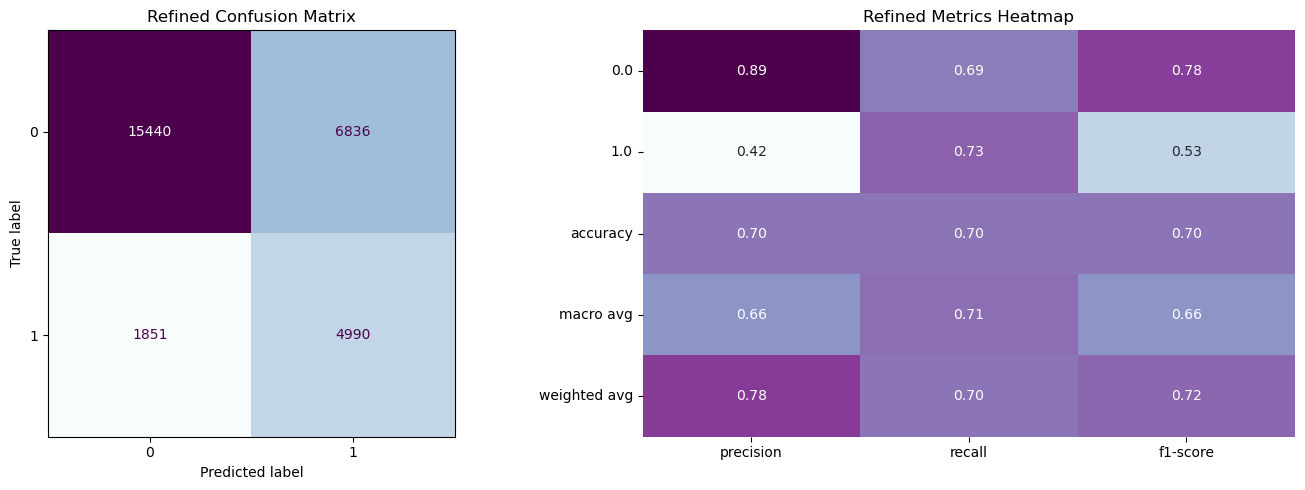

In [261]:
y_pred_final = best_model_final.predict(x_test)
report_final = classification_report(y_test, y_pred_final, output_dict=True)
report_df_final = pd.DataFrame(report_final).iloc[:-1, :].T

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final).plot(cmap='BuPu', ax=ax[0], colorbar=False)
ax[0].set_title('Refined Confusion Matrix')

# Right: Classification Report Heatmap
sns.heatmap(report_df_final, annot=True, cmap='BuPu', cbar=False, ax=ax[1], fmt='.2f')
ax[1].set_title('Refined Metrics Heatmap')

plt.tight_layout()
plt.show()

## Model Evaluation

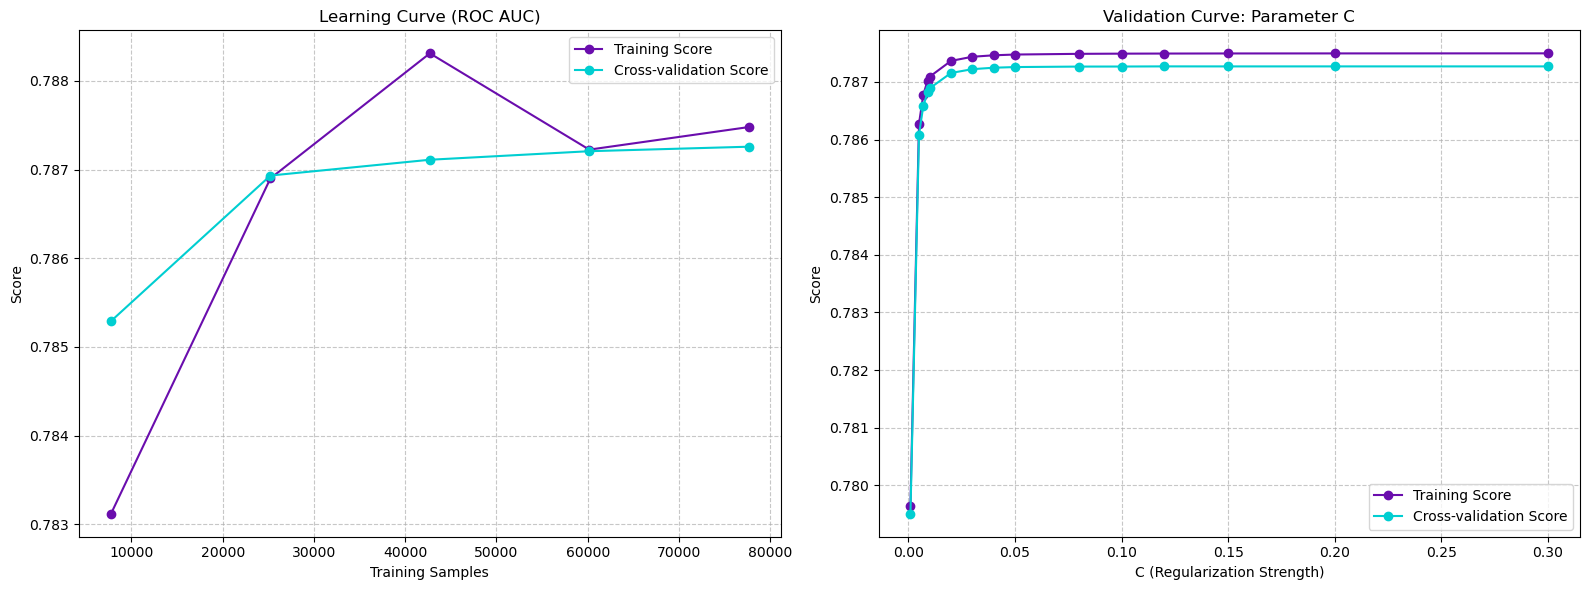

In [262]:
from sklearn.model_selection import learning_curve, validation_curve

# Configuration
best_model = grid_search.best_estimator_
c_range = param_grid_narrow['C']

# Create Figure
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. Learning Curve (Left) ---
train_sizes, train_scores, test_scores = learning_curve(
    best_model, x_train, y_train, cv=cv_fast, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='roc_auc'
)

ax[0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Training Score", color="#6a0dad")
ax[0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Cross-validation Score", color="#00ced1")
ax[0].set_title("Learning Curve (ROC AUC)")
ax[0].set_xlabel("Training Samples")
ax[0].set_ylabel("Score")
ax[0].legend(loc="best")
ax[0].grid(True, linestyle='--', alpha=0.7)

# --- 2. Validation Curve (Right) ---
train_scores_vc, test_scores_vc = validation_curve(
    best_model, x_train, y_train, param_name="C", param_range=c_range,
    cv=cv_fast, scoring="roc_auc", n_jobs=-1
)

ax[1].plot(c_range, np.mean(train_scores_vc, axis=1), 'o-', label="Training Score", color="#6a0dad")
ax[1].plot(c_range, np.mean(test_scores_vc, axis=1), 'o-', label="Cross-validation Score", color="#00ced1")
ax[1].set_title("Validation Curve: Parameter C")
ax[1].set_xlabel("C (Regularization Strength)")
ax[1].set_ylabel("Score")
ax[1].legend(loc="best")
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Model Adjusting

In [263]:
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

prod_pipeline = Pipeline([
    # Add your preprocessing steps here if they aren't already in the model
    ('calibration', CalibratedClassifierCV(best_model_final, cv='prefit', method='sigmoid'))
])

# Fit calibration using the test/validation set
prod_pipeline.fit(x_test, y_test)

# Now you can save this single object
# import joblib
# joblib.dump(prod_pipeline, 'pd_model_v1.pkl')

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,steps,"[('calibration', ...)]"
,transform_input,None
,memory,None
,verbose,False
,estimator,LogisticRegre...max_iter=1000)
,method,'sigmoid'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,dual,False


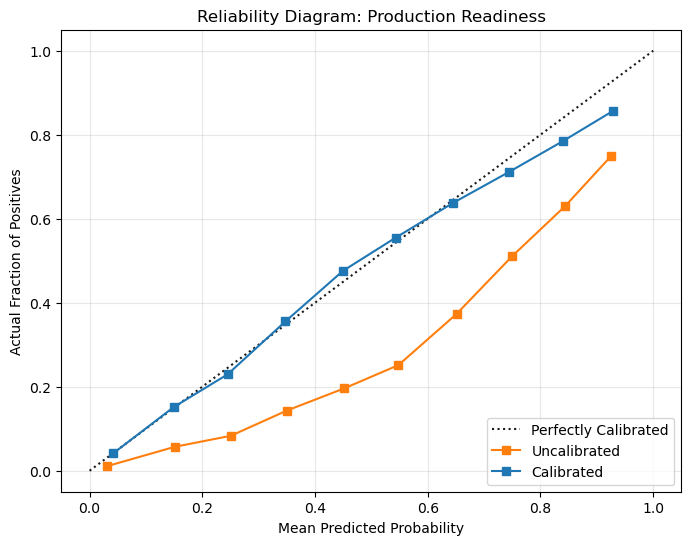

In [264]:
def plot_calibration_comparison(y_true, model_uncal, model_cal, X_eval):
    plt.figure(figsize=(8, 6))
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
    
    for model, label, color in [(model_uncal, 'Uncalibrated', '#ff7f0e'), 
                                (model_cal, 'Calibrated', '#1f77b4')]:
        probs = model.predict_proba(X_eval)[:, 1]
        fop, mpv = calibration_curve(y_true, probs, n_bins=10)
        plt.plot(mpv, fop, "s-", label=label, color=color)

    plt.ylabel("Actual Fraction of Positives")
    plt.xlabel("Mean Predicted Probability")
    plt.title("Reliability Diagram: Production Readiness")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Usage:
plot_calibration_comparison(y_test, best_model_final, prod_pipeline, x_test)

In [265]:
# 1. Get calibrated probabilities
calibrator = prod_pipeline.named_steps['calibration']
y_probs = calibrator.predict_proba(x_test)[:, 1]

# 2. Generate metrics
thresholds = np.linspace(0, 1, 20)
stats = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    approval_rate = (y_pred_t == 0).mean() * 100
    
    stats.append({
        'Threshold': round(t, 3),
        'Approval %': round(approval_rate, 2),
        'False Positives (FP)': fp,
        'False Negatives (FN)': fn
    })

# 3. Create and Display DataFrame
error_df = pd.DataFrame(stats)
print(error_df.to_string(index=False))

 Threshold  Approval %  False Positives (FP)  False Negatives (FN)
     0.000        0.00                 22276                     0
     0.053       16.65                 17542                   115
     0.105       29.25                 14134                   375
     0.158       42.05                 10913                   880
     0.211       54.24                  8008                  1524
     0.263       64.64                  5645                  2191
     0.316       72.50                  3979                  2812
     0.368       77.57                  3043                  3354
     0.421       82.23                  2213                  3879
     0.474       86.49                  1596                  4504
     0.526       90.85                   974                  5152
     0.579       93.72                   609                  5620
     0.632       95.79                   361                  5975
     0.684       97.27                   216                  

<Figure size 640x480 with 0 Axes>

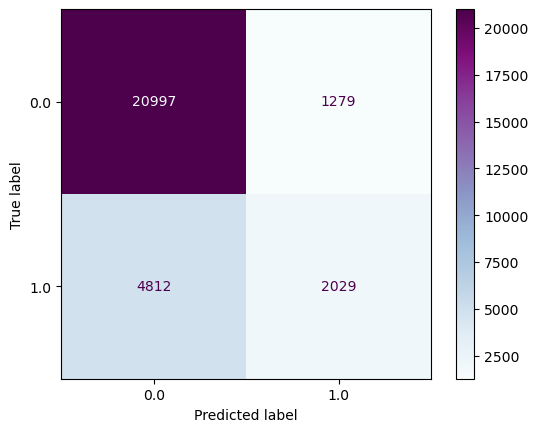

In [266]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, calibrator.predict(x_test), cmap= 'BuPu')
plt.show()

## PD Model

In [267]:
# Scaling Parameters
pdo, target_score, target_odds = 20, 600, 50
factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

intercept = best_model.intercept_[0]
coefficients = best_model.coef_[0]
feature_names = x_train.columns
scorecard_list = []

# 1. Base Score (Intercept Correction)
base_points = round(offset - (intercept * factor))
scorecard_list.append({'Variable': 'Base Score', 'Bin': 'Intercept', 'Points': base_points})

# 2. Variable Bins (Sign Correction)
for i, feature in enumerate(feature_names):
    bin_table = bin_proc.get_binned_variable(feature).binning_table.build()
    for _, row in bin_table.iterrows():
        if row['Bin'] in ['Total', 'Special', 'Missing']: continue
        
        woe = float(row['WoE']) if str(row['WoE']).strip() not in ['', 'nan'] else 0.0
        # Points = -(WoE * Beta * Factor)
        point = round(-(woe * coefficients[i] * factor))
        
        scorecard_list.append({'Variable': feature, 'Bin': row['Bin'], 'Points': point})

scorecard_df = pd.DataFrame(scorecard_list)
scorecard_df

,Variable,Bin,Points
0,Base Score,Intercept,487
1,Gender,[Joint],18
2,Gender,[Female],-2
3,Gender,[Male],-4
4,Gender,[Sex Not Available],-11
...,...,...,...
97,interest_burden,"[0.03, 0.03)",2
98,interest_burden,"[0.03, inf)",3
99,interest_burden,,0
100,loan_count,"(-inf, inf)",0


In [268]:
# Calculate Scores: Base - (Risk Components)
# Using the negative dot product to align with the table logic
total_scores = base_points - (x_test.values @ (coefficients * factor))

borrower_results = pd.DataFrame({
    'Total_Score': total_scores.astype(int),
    'PD (%)': np.round(prod_pipeline.predict_proba(x_test)[:, 1] * 100, 2),
    'Actual_Default': y_test.values
}, index=x_test.index)

print(borrower_results.sort_values('Total_Score', ascending=False).head())

        Total_Score  PD (%)  Actual_Default
52686           757     0.0             0.0
16945           757     0.0             0.0
63321           755     0.0             0.0
141094          755     0.0             0.0
144433          753     0.0             0.0


## EL model

In [269]:
# 1. Access raw data for the test set
df_raw_test = df.loc[x_test.index]

# 2. PD (Calibrated) from our pipeline
pd_values = prod_pipeline.predict_proba(x_test)[:, 1]

# 3. Construct EL Table
el_table = pd.DataFrame(index=x_test.index)
el_table['PD'] = pd_values
el_table['EAD'] = df_raw_test['loan_amount']

# 4. Estimate LGD: A common scientific proxy is LTV adjusted by a recovery factor
# Higher LTV = Higher risk of loss. 
# We assume 25% costs for liquidation/legal (Recovery = Collateral - Costs)
el_table['LGD'] = (df_raw_test['LTV'] / 100) * 0.75
el_table['LGD'] = el_table['LGD'].clip(0.1, 1.0) # Cap loss between 10% and 100%

# 5. Final EL Calculation
el_table['Expected_Loss'] = el_table['PD'] * el_table['LGD'] * el_table['EAD']

print(el_table[['PD', 'EAD', 'LGD', 'Expected_Loss']].head())

              PD        EAD       LGD  Expected_Loss
59927   0.112565  1106500.0  0.597893   74469.446719
82950   0.344339   656500.0  0.705408  159463.584926
60283   0.175182   146500.0  0.461660   11848.137230
110498  0.000135   316500.0  0.645041      27.465221
117593  0.411266  1596500.0  0.554854  364309.709168


## Statistics

In [270]:
total_ead = el_table['EAD'].sum()
total_el = el_table['Expected_Loss'].sum()
wapd = (el_table['PD'] * el_table['EAD']).sum() / total_ead
el_rate_bps = (total_el / total_ead) * 10000
# 1. Calculate Revenue (Estimated Interest Income)
# (Rate of Interest / 100) * EAD * (1 - PD) 
# We multiply by (1-PD) because defaulted loans stop paying interest.
el_table['Revenue'] = (df_raw_test['rate_of_interest'] / 100) * el_table['EAD'] * (1 - el_table['PD'])
# 1. Financial Aggregates
total_revenue = el_table['Revenue'].sum()
net_income_expected = total_revenue - total_el

# 2. Stress Test / Worst Case (Unexpected Loss Estimate)
# Standard deviation of losses helps estimate the 'tail risk'
loss_std = el_table['Expected_Loss'].std()
worst_case_loss = total_el + (3.09 * loss_std * np.sqrt(len(el_table))) # 99.9% Confidence Interval
worst_case_profit = total_revenue - worst_case_loss

# 3. Efficiency Metrics
raroc = (net_income_expected / (worst_case_loss - total_el)) * 100 # Risk-Adjusted Return on Capital
cost_of_risk = (total_el / total_ead) * 100

def segment_risk(score):
    if score >= 600: return '1. Low Risk'
    if score >= 450: return '2. Medium Risk'
    return '3. High Risk'

el_table['Score'] = total_scores.astype(int)
el_table['Segment'] = el_table['Score'].apply(segment_risk)

# 3. Aggregate Metrics by Segment
exec_summary = el_table.groupby('Segment').agg({
    'PD': 'mean',
    'EAD': ['count', 'sum'],
    'Expected_Loss': 'sum',
    'Revenue': 'sum'
})

# Flatten columns and calculate Risk-Adjusted Profit
exec_summary.columns = ['Avg_PD', 'Loan_Count', 'Total_EAD', 'Total_EL', 'Total_Revenue']
exec_summary['EL_Rate_%'] = (exec_summary['Total_EL'] / exec_summary['Total_EAD']) * 100
exec_summary['Net_Profit'] = exec_summary['Total_Revenue'] - exec_summary['Total_EL']


# 4. Total Portfolio EL Rate
overall_el_rate = (el_table['Expected_Loss'].sum() / el_table['EAD'].sum()) * 100


# --- OUTPUT ---
print(f"--- PORTFOLIO EXECUTIVE SUMMARY ---")
print(f"Total Exposure (EAD):        ${total_ead:,.2f}")
print(f"Gross Interest Revenue:      ${total_revenue:,.2f}")
print(f"Expected Loss (EL):          ${total_el:,.2f}")
print(f"---------------------------------------")
print(f"Net Risk-Adjusted Income:    ${net_income_expected:,.2f}")
print(f"Portfolio EL Rate:           {cost_of_risk:.2f}%")
print(f"---------------------------------------")
print(f"STRESS TEST (99.9% Confidence)")
print(f"Worst-Case Total Loss:       ${worst_case_loss:,.2f}")
print(f"Worst-Case Net Profit:       ${worst_case_profit:,.2f}")
print(f"Economic Capital Required:   ${(worst_case_loss - total_el):,.2f}")
print(f"RAROC:                       {raroc:.2f}%")


print('------------------------------------------')

print(exec_summary.to_string())
print(f"\nOverall Portfolio Expected Loss Rate: {overall_el_rate:.2f}%")

--- PORTFOLIO EXECUTIVE SUMMARY ---
Total Exposure (EAD):        $9,640,760,500.00
Gross Interest Revenue:      $298,211,436.66
Expected Loss (EL):          $1,206,906,429.06
---------------------------------------
Net Risk-Adjusted Income:    $-908,694,992.40
Portfolio EL Rate:           12.52%
---------------------------------------
STRESS TEST (99.9% Confidence)
Worst-Case Total Loss:       $1,231,086,933.48
Worst-Case Net Profit:       $-932,875,496.83
Economic Capital Required:   $24,180,504.43
RAROC:                       -3757.97%
------------------------------------------
                  Avg_PD  Loan_Count     Total_EAD      Total_EL  Total_Revenue  EL_Rate_%    Net_Profit
Segment                                                                                                 
1. Low Risk     0.000333        1816  6.701140e+08  1.129278e+05   2.426728e+07   0.016852  2.415435e+07
2. Medium Risk  0.208914       24690  8.232515e+09  9.296071e+08   2.627706e+08  11.291896 -6.6683

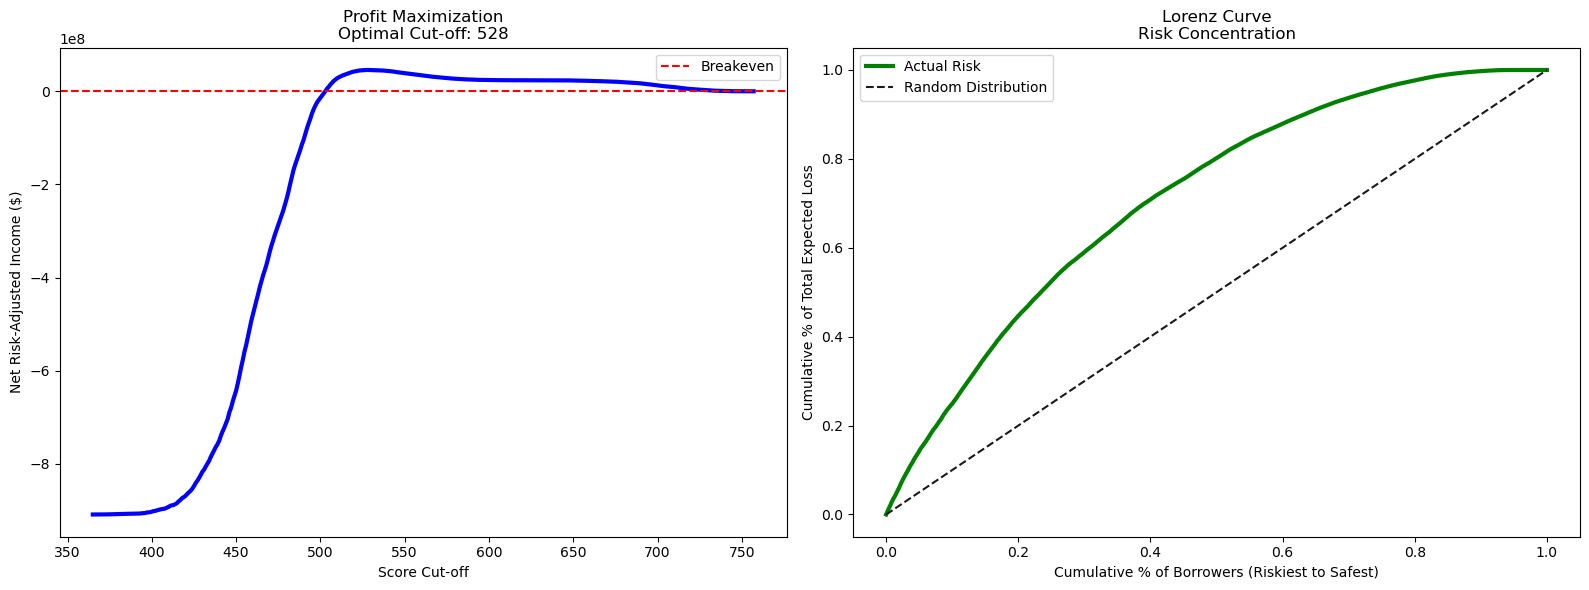

In [271]:
# 1. Add Scores to the EL Table for alignment
el_table['Score'] = total_scores.astype(int)

# 2. Profit Maximization Curve Data
cutoffs = np.sort(el_table['Score'].unique())
profit_data = []

for c in cutoffs:
    # Filter for borrowers meeting the cut-off
    approved = el_table[el_table['Score'] >= c]
    # Net Profit = Total Revenue - Total Expected Loss
    # Note: Ensure 'Revenue' column exists in el_table from previous steps
    net_income = el_table.loc[approved.index, 'Revenue'].sum() - approved['Expected_Loss'].sum()
    profit_data.append(net_income)

# 3. Lorenz Curve Data (Risk Concentration)
# Sort by score ascending (riskiest first)
lorenz_df = el_table.sort_values('Score')
lorenz_df['cum_pop'] = np.arange(1, len(lorenz_df) + 1) / len(lorenz_df)
lorenz_df['cum_el'] = lorenz_df['Expected_Loss'].cumsum() / lorenz_df['Expected_Loss'].sum()

# 4. Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Profit Curve
ax1.plot(cutoffs, profit_data, color='blue', lw=3)
ax1.axhline(0, color='red', linestyle='--', label='Breakeven')
optimal_score = cutoffs[np.argmax(profit_data)]
ax1.set_title(f'Profit Maximization\nOptimal Cut-off: {optimal_score}')
ax1.set_xlabel('Score Cut-off')
ax1.set_ylabel('Net Risk-Adjusted Income ($)')
ax1.legend()

# Plot 2: Lorenz Curve
ax2.plot(lorenz_df['cum_pop'], lorenz_df['cum_el'], color='green', lw=3, label='Actual Risk')
ax2.plot([0, 1], [0, 1], 'k--', label='Random Distribution')
ax2.set_title('Lorenz Curve\nRisk Concentration')
ax2.set_xlabel('Cumulative % of Borrowers (Riskiest to Safest)')
ax2.set_ylabel('Cumulative % of Total Expected Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [272]:
# Count how many borrowers are actually 'profitable'
profitable_count = (el_table['Revenue'] > el_table['Expected_Loss']).sum()
total_count = len(el_table)

print(f"Profitable Borrowers: {profitable_count} out of {total_count}")

if profitable_count == 0:
    print("CRITICAL: No breakeven possible. Every segment is losing money.")
else:
    print(f"Breakeven is possible if you only approve the top {profitable_count} borrowers.")

Profitable Borrowers: 6343 out of 29117
Breakeven is possible if you only approve the top 6343 borrowers.


## PSI & CSI

In [273]:
def calculate_psi(expected, actual, buckets=10):
    # 1. Define buckets based on expected (training) data
    breakpoints = np.percentile(expected, np.arange(0, 101, 100 / buckets))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf # Ensure full coverage
    
    # 2. Count frequencies in each bucket
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # 3. Handle zero counts to avoid log(0)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    
    # 4. Formula: (Actual% - Expected%) * ln(Actual% / Expected%)
    psi_values = (actual_percents - expected_percents) * np.log(actual_percents / expected_percents)
    return np.sum(psi_values)

# --- PSI: Score Stability ---
# Compare training scores vs test scores
train_scores = (x_train.values @ (coefficients * factor)) + base_points # Logic from earlier
psi_score = calculate_psi(train_scores, el_table['Score'])

# --- CSI: Feature Stability (Example: loan_amount) ---
csi_loan = calculate_psi(df.loc[x_train.index, 'loan_amount'], df.loc[x_test.index, 'loan_amount'])

print(f"Portfolio PSI: {psi_score:.4f}")
print(f"Loan Amount CSI: {csi_loan:.4f}")

Portfolio PSI: 0.3837
Loan Amount CSI: 0.0003


In [274]:
# Check basic stats of scores for both sets
print("Train Score Mean:", train_scores.mean())
print("Test Score Mean: ", el_table['Score'].mean())

print("\nTrain Score Std:", train_scores.std())
print("Test Score Std: ", el_table['Score'].std())

Train Score Mean: 468.3189176305527
Test Score Mean:  505.26050073840025

Train Score Std: 59.25398615091089
Test Score Std:  59.90252451604488


In [ ]:
# add xgboost to asses your model and flag when its behaving weirdly.

In [ ]:
# Check basic stats of scores for both sets
print("Train Score Mean:", train_scores.mean())
print("Test Score Mean: ", el_table['Score'].mean())

print("\nTrain Score Std:", train_scores.std())
print("Test Score Std: ", el_table['Score'].std())